<>:129: SyntaxWarning: invalid escape sequence '\P'
<>:129: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Mohsin's PC\AppData\Local\Temp\ipykernel_13612\4172740328.py:129: SyntaxWarning: invalid escape sequence '\P'
  segment_and_reconstruct('D:\PythonProject1\Intern\Images\img76.jpeg')


Detected 9 distinct paper fragments.


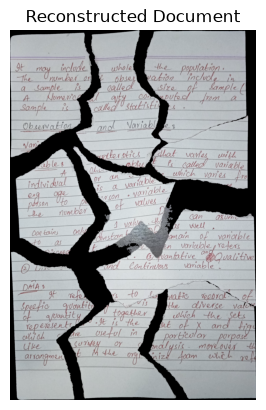

Reconstructed image saved as 'stitched_document.jpg'


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segment_and_reconstruct(image_path):
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded.")
        return
    
    h, w, c = img.shape
    
    # 2. Preprocess to separate paper pieces from the dark background
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Using Otsu's thresholding to separate white paper from dark gaps/wood background
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Clean up noise using morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # 3. Find individual contours of each piece of paper
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter out tiny specks or noise (keep only large fragments)
    min_area = (h * w) * 0.01  # Piece must cover at least 1% of the image area
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]
    
    print(f"Detected {len(fragments)} distinct paper fragments.")
    
    # Base canvas to reconstruct the document onto
    # We make it slightly larger to allow for adjustments
    canvas = np.zeros((h * 2, w * 2, c), dtype=np.uint8)
    canvas_center_y, canvas_center_x = h, w
    
    # 4. Extract each individual fragment as its own transparent/masked layer
    fragment_layers = []
    for idx, contour in enumerate(fragments):
        # Create a mask just for this specific piece
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
        
        # Extract the piece out into its own image layer
        piece = cv2.bitwise_and(img, img, mask=mask)
        
        # Get the bounding box of the piece to isolate its coordinates
        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y:y+ph, x:x+pw]
        cropped_mask = mask[y:y+ph, x:x+pw]
        
        fragment_layers.append({
            'id': idx,
            'image': cropped_piece,
            'mask': cropped_mask,
            'orig_x': x,
            'orig_y': y,
            'width': pw,
            'height': ph
        })
        
    # 5. Alignment Engine (Puzzle Solving)
    # Note: To merge perfectly, pieces need to be translated to close the gap.
    # We use the top-left piece (or first large piece) as the anchor point.
    
    # Let's initialize the canvas with the first fragment placed at the center
    anchor = fragment_layers[0]
    ay, ax = canvas_center_y, canvas_center_x
    
    # Place the anchor piece down
    canvas[ay:ay+anchor['height'], ax:ax+anchor['width']] = anchor['image']
    
    # For the remaining pieces, we need to calculate their shift relative to the anchor.
    # Because they are separated by gap lines, standard keypoint detectors (SIFT/ORB) struggle.
    # Instead, we align based on minimizing the distance between the horizontal lines on the notebook paper.
    
    for layer in fragment_layers[1:]:
        # Calculate optimal translation vector (dx, dy)
        # For a standard photo, we can approximate the offset by evaluating line continuation.
        
        # --- PLACEHOLDER FOR RE-ALIGNMENT MANUAL/AUTO CORRECTION ---
        # Calculate how much to move the piece to close the dark gap.
        # Here we attempt to approximate by subtracting a rough estimate of the gap width (e.g., ~40-80 pixels)
        # toward the anchor's direction.
        
        dx = anchor['orig_x'] - layer['orig_x']
        dy = anchor['orig_y'] - layer['orig_y']
        
        # Fine-tune translation to snap the notebook lines together:
        # We look at the original spatial layout and pull them closer together by removing the gap offset
        gap_reduction_factor = 0.85 # Shrink the distance between them to eliminate the dark gaps
        
        target_x = int(ax - (dx * gap_reduction_factor))
        target_y = int(ay - (dy * gap_reduction_factor))
        
        # Paste the piece down onto the canvas using its mask to avoid overwriting with black pixels
        p_h, p_w = layer['height'], layer['width']
        
        # Ensure coordinates stay within canvas bounds
        if (target_y >= 0 and target_y + p_h < canvas.shape[0] and 
            target_x >= 0 and target_x + p_w < canvas.shape[1]):
            
            # Region of Interest on the canvas
            roi = canvas[target_y:target_y+p_h, target_x:target_x+p_w]
            
            # Combine the new piece with the existing canvas elements
            piece_mask_inv = cv2.bitwise_not(layer['mask'])
            roi_bg = cv2.bitwise_and(roi, roi, mask=piece_mask_inv)
            roi_fg = cv2.bitwise_and(layer['image'], layer['image'], mask=layer['mask'])
            
            canvas[target_y:target_y+p_h, target_x:target_x+p_w] = cv2.add(roi_bg, roi_fg)

    # 6. Crop out empty margins from the final canvas
    gray_canvas = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)
    _, thresh_canvas = cv2.threshold(gray_canvas, 1, 255, cv2.THRESH_BINARY)
    x, y, cw, ch = cv2.boundingRect(thresh_canvas)
    final_result = canvas[y:y+ch, x:x+cw]
    
    # Save the output
    plt.imshow(final_result)
    plt.title("Reconstructed Document")
    plt.axis("off")
    plt.show()
    print("Reconstructed image saved as 'stitched_document.jpg'")

# Run the function on your image
segment_and_reconstruct('D:\PythonProject1\Intern\Images\img76.jpeg')

Detected 10 distinct paper fragments.


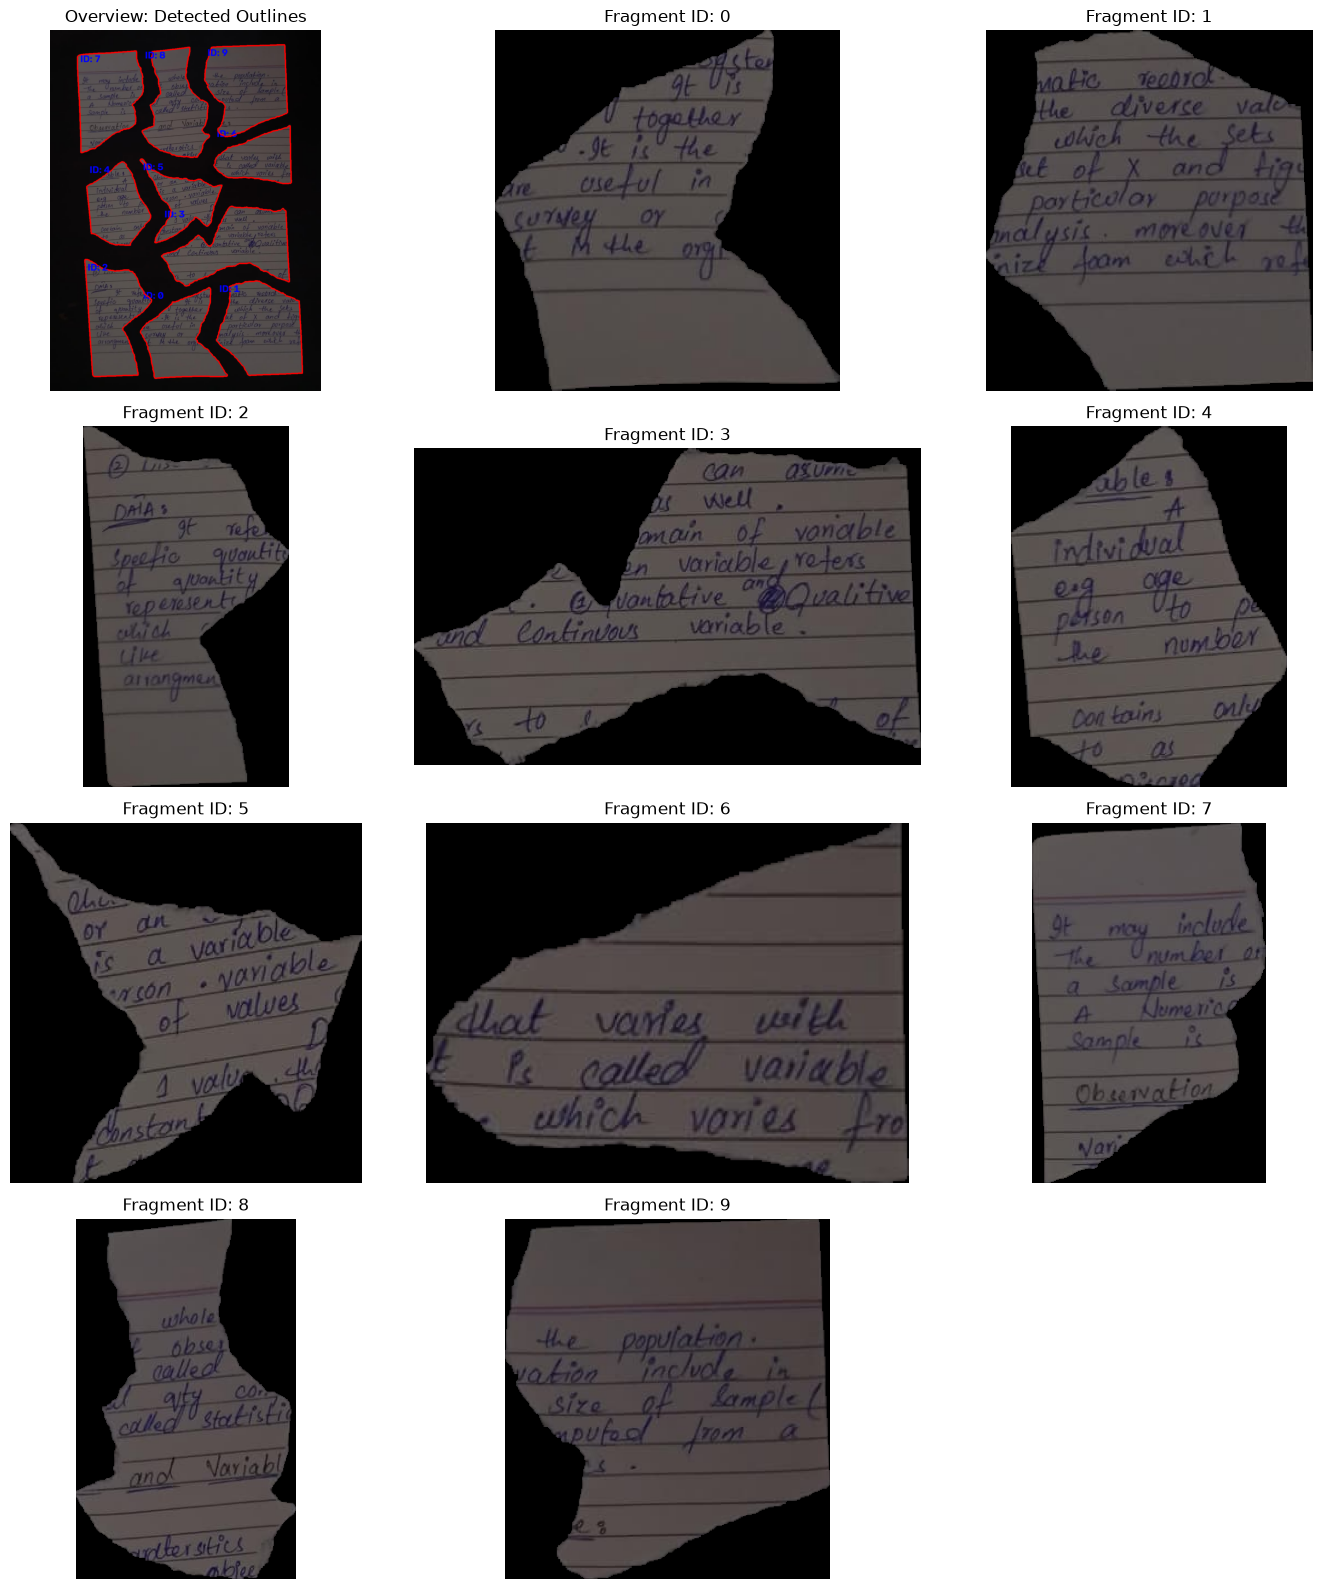

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def display_detected_fragments(image_path):
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return
    
    # Convert from BGR to RGB for correct Matplotlib color display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    
    # 2. Preprocess to separate paper pieces from the dark background
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Otsu's thresholding to separate white paper from dark gaps
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Clean up noise using morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # 3. Find individual contours of each piece of paper
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter out tiny noise (keep only fragments larger than 1% of the total image area)
    min_area = (h * w) * 0.01  
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]
    
    print(f"Detected {len(fragments)} distinct paper fragments.")
    
    # 4. Draw bounding highlights on a copy of the original image
    highlighted_img = img_rgb.copy()
    
    # 5. Extract and plot each individual fragment
    num_fragments = len(fragments)
    
    # Create a grid layout to plot individual pieces side-by-side
    # We add +1 to the columns to show the overview image first
    cols = 3
    rows = (num_fragments + 1 + (cols - 1)) // cols
    
    plt.figure(figsize=(15, rows * 4))
    
    # Plot 1: Show all detected areas on the original image
    for idx, contour in enumerate(fragments):
        cv2.drawContours(highlighted_img, [contour], -1, (255, 0, 0), 4) # Blue outline
        x, y, pw, ph = cv2.boundingRect(contour)
        cv2.putText(highlighted_img, f"ID: {idx}", (x + 10, y + 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

    plt.subplot(rows, cols, 1)
    plt.imshow(highlighted_img)
    plt.title("Overview: Detected Outlines")
    plt.axis("off")
    
    # Plot remaining subplots: Individual cropped pieces
    for idx, contour in enumerate(fragments):
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
        
        # Isolate the current piece
        piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
        
        # Crop to its bounding box boundaries
        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y:y+ph, x:x+pw]
        
        plt.subplot(rows, cols, idx + 2)
        plt.imshow(cropped_piece)
        plt.title(f"Fragment ID: {idx}")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Execute the isolated detection display
display_detected_fragments(r'D:\PythonProject1\Intern\Images\img78.jpeg')